### Instalar as bibliotecas necessárias:

Abra o terminal e execute os seguintes comandos:

In [1]:
pip install pandas pyarrow duckdb matplotlib

  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached pyarrow-24.0.0-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached duckdb-1.5.2-cp314-cp314-win_amd64.whl.metadata (4.2 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached pyarrow-24.0.0-cp314-cp314-win_amd64.whl (28.0 MB)
Using cached duckdb-1.5.2-cp314-cp314-win_amd64.whl (13.6 MB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -----------------------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Baixar o conjunto de dados:

    Baixe um arquivo CSV grande (ex.: logs de navegação ou vendas) ou gere um conjunto de dados sintético usando Python:

In [6]:
import pandas as pd
import numpy as np

# Gerar dados sintéticos
data = {
    "UserID": np.random.randint(1, 1000, 1000000),
    "Timestamp": pd.date_range(start="2023-01-01", periods=1000000, freq="s"),
    "URLVisitada": [f"pagina_{i % 10}" for i in range(1000000)],
    "TempoSessao": np.random.randint(10, 300, 1000000)
}
df = pd.DataFrame(data)
df.to_csv("dados_logs.csv", index=False)


### Converter o CSV para formato colunar (Parquet):

    Use o Pandas para converter o CSV em um arquivo Parquet:

In [7]:
import pandas as pd

# Ler o CSV
df = pd.read_csv("dados_logs.csv")

# Salvar como Parquet
df.to_parquet("dados_logs.parquet", engine="pyarrow")

### Parte 2: Consultas Analíticas

    Carregar o arquivo Parquet com DuckDB:
        DuckDB é uma ferramenta leve que suporta consultas SQL em arquivos Parquet. Execute o seguinte código:

In [8]:
import duckdb

# Conectar ao DuckDB
con = duckdb.connect()

# Carregar o arquivo Parquet
con.execute("CREATE TABLE logs AS SELECT * FROM read_parquet('dados_logs.parquet')")

### Executar consultas analíticas:

    Execute consultas SQL para explorar os dados:

In [9]:
# Contagem de visitas por página
result = con.execute("""
    SELECT URLVisitada, COUNT(*) AS TotalVisitas
    FROM logs
    GROUP BY URLVisitada
    ORDER BY TotalVisitas DESC
""").fetchall()

print(result)

# Média de tempo de sessão por usuário
result = con.execute("""
    SELECT UserID, AVG(TempoSessao) AS MediaTempoSessao
    FROM logs
    GROUP BY UserID
    ORDER BY MediaTempoSessao DESC
""").fetchall()

print(result)

[('pagina_3', 100000), ('pagina_6', 100000), ('pagina_8', 100000), ('pagina_0', 100000), ('pagina_5', 100000), ('pagina_7', 100000), ('pagina_9', 100000), ('pagina_1', 100000), ('pagina_2', 100000), ('pagina_4', 100000)]
[(761, 163.73558215451578), (440, 163.2766990291262), (801, 162.31635651322233), (290, 162.2115971515768), (113, 161.69700214132763), (378, 161.64012096774192), (709, 161.2743271221532), (971, 161.03995901639345), (917, 161.0125968992248), (822, 160.967112024666), (218, 160.9306742640076), (246, 160.90368852459017), (139, 160.67586206896553), (368, 160.61013443640124), (382, 160.46509240246405), (329, 160.37547169811322), (345, 160.28232971372162), (523, 160.24677898909812), (424, 160.193074501574), (238, 160.152), (65, 160.1473087818697), (309, 160.1358529111338), (331, 160.0207100591716), (840, 159.9346153846154), (4, 159.89711934156378), (418, 159.88117770767613), (347, 159.86439024390245), (544, 159.79222108495395), (21, 159.71905697445973), (338, 159.6639511201629

### Comparar desempenho entre CSV e Parquet:

    Compare o tempo de execução das mesmas consultas em um arquivo CSV e no arquivo Parquet:

In [13]:
import time

# Consulta no CSV
start_time = time.time()
df_csv = pd.read_csv("dados_logs.csv")
df_csv.groupby("URLVisitada").size().reset_index(name="TotalVisitas")
print(f"Tempo CSV: {time.time() - start_time}")

# Consulta no Parquet
start_time = time.time()
df_parquet = pd.read_parquet("dados_logs.parquet")
df_parquet.groupby("URLVisitada").size().reset_index(name="TotalVisitas")
print(f"Tempo Parquet: {time.time() - start_time}")

Tempo CSV: 0.5644941329956055
Tempo Parquet: 0.0436711311340332


### Parte 3: Análise dos Resultados

    Discussão em sala:
        Quais foram as diferenças de desempenho entre o CSV e o Parquet?
        Por que o formato colunar (Parquet) é mais eficiente para consultas analíticas?
    Visualização dos dados:
        Use uma ferramenta gráfica (ex.: Matplotlib ou Seaborn) para visualizar os resultados das consultas:

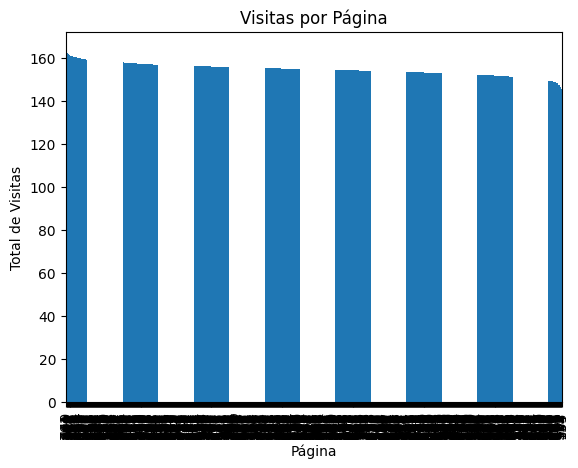

In [14]:
import matplotlib.pyplot as plt

# Visualizar contagem de visitas por página
df_result = pd.DataFrame(result, columns=["URLVisitada", "TotalVisitas"])
df_result.plot(kind="bar", x="URLVisitada", y="TotalVisitas", legend=False)
plt.title("Visitas por Página")
plt.xlabel("Página")
plt.ylabel("Total de Visitas")
plt.show()

### Conclusão

    Resumo:
        Bancos de dados colunares, como o Amazon Redshift, utilizam formatos semelhantes ao Parquet para otimizar consultas analíticas.
        O formato colunar reduz o tempo de leitura e melhora o desempenho em grandes volumes de dados.
    Reflexão:
        Em quais cenários você usaria um banco de dados colunar em vez de um relacional?